# Осечки при стрельбе

Владелец тира заметил, что увеличилось количество жалоб на осечки при стрельбе из ружья. Осечка - это отсутствие выстрела при производстве стрельбы вследствие неисправности огнестрельного оружия или патрона. Инструкторы тира подтвердили, что примерно каждая пятая попытка выстрела заканчивается осечкой.

Решили проверить гипотезу о равенстве долей осечек при стрельбе патронами разных производителей. Поочерёдно будут заряжать по одному патрону от одного и от другого производителя и делать выстрел. Для каждого выстрела отмечать была осечка или нет. Уровень значимости и допустимая вероятность ошибки второго рода равны 0.1. Ожидаем, что доля осечек уменьшится с 0.2 до 0.1.

## Задание 1 (2 балла). Размеры групп

Сколько выстрелов нужно сделать патронами от каждого производителя, чтобы проверить гипотезу с заданными допустимыми вероятностями ошибок классическим способом (без техник последовательного тестирования)?

С помощью синтетических АА и АБ тестов проверьте, что для полученного размера групп вероятности ошибок контролируются на заданных уровнях.

In [1]:
from typing import Dict, Tuple, Callable
from collections import defaultdict

import numpy as np
from scipy import stats

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
def get_sample_size(alpha: float, beta: float, p0: float, p1: float) -> int:
    n = 1
    while stats.binom.ppf(1 - beta, n, p0) >= stats.binom.ppf(alpha, n, p1):
        n += 1

    return n


alpha = beta = 0.1
p0 = 0.1
p1 = 0.2

var1 = p0 * (1 - p0)
var2 = p1 * (1 - p1)

In [3]:
def plot_pvalue_distribution_power(
    dict_pvalues: Dict[str, np.ndarray], alpha: float = 0.05
):
    X = np.linspace(0, 1, 1000)
    for key, pvalues in dict_pvalues.items():
        Y = np.searchsorted(np.sort(pvalues), X) / len(pvalues)
        prob_p = np.mean(np.array(pvalues) < alpha)
        plt.plot(X, Y, label=f"{key}, prob_p={prob_p:0.2f}")
    plt.plot([alpha, alpha], [0, 1], "--k", alpha=0.8)
    plt.plot([0, 1], [0, 1], "--k", alpha=0.8)
    plt.title("Оценка распределения p-value", size=16)
    plt.xlabel("p-value", size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

100%|██████████| 1000/1000 [00:01<00:00, 512.04it/s]


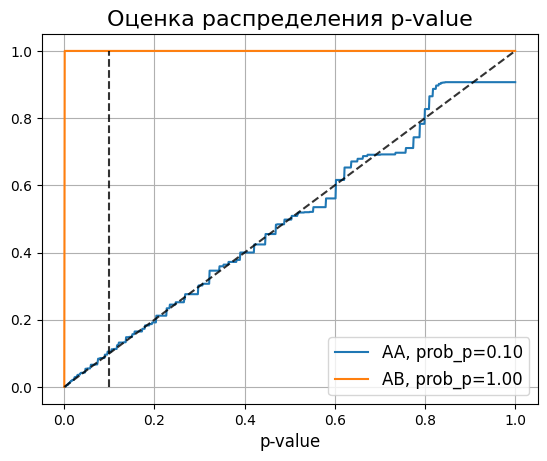

In [4]:
n_experiments = 1000
n = get_sample_size(alpha, beta, p0, p1) 

dict_pvalues = defaultdict(list)

for _ in tqdm(range(n_experiments)):
    a1, a2 = np.random.binomial(1, p0, size=(2, n))
    b = np.random.binomial(n, p1, size=n)

    dict_pvalues["AA"].append(stats.ttest_ind(a1, a2)[1])
    dict_pvalues["AB"].append(stats.ttest_ind(a1, b)[1])

plot_pvalue_distribution_power(dict_pvalues, alpha=alpha)

Значимость получилась примерно $0.1$, мощность примерно $1.0$. Ошибки первого и второго рода контролируются на заданных уровнях

## Задание 2 (3 балла). Критерий Вальда

Примените к этой задаче критерий Вальда. Можно взять функцию `test_sequential_wald` с семинара. Пока оставим приближение нормальным распределением в функциях `pdf_a` и `pdf_b`. Не забудьте скорректировать значения эффекта и std в параметрах распределений.

- Оцените вероятности ошибок первого и второго рода. Корректно ли работает критерий?
- Оцените средний размер групп до остановки теста.

In [5]:
def pdf_a_norm(x: np.ndarray) -> np.ndarray:
    return stats.norm.pdf(x, loc=0, scale=np.sqrt(var1 + var2))


def pdf_b_norm(x: np.ndarray) -> np.ndarray:
    return stats.norm.pdf(x, loc=0.1, scale=np.sqrt(var1 + var2))


def test_sequential_wald(
    x: np.ndarray,
    pdf_a: Callable[[np.ndarray], np.ndarray],
    pdf_b: Callable[[np.ndarray], np.ndarray],
    alpha: float,
    beta: float,
) -> Tuple[int, int, np.ndarray]:
    size = len(x)
    lower_bound = np.log(beta / (1 - alpha))
    upper_bound = np.log((1 - beta) / alpha)

    pdf_a_values = pdf_a(x)
    pdf_b_values = pdf_b(x)
    z = np.cumsum(np.log(pdf_b_values / pdf_a_values))

    indexes_lower = np.arange(size)[z < lower_bound]
    indexes_upper = np.arange(size)[z > upper_bound]
    first_index_lower = indexes_lower[0] if len(indexes_lower) > 0 else size + 1
    first_index_upper = indexes_upper[0] if len(indexes_upper) > 0 else size + 1

    if first_index_lower < first_index_upper:
        return 0, first_index_lower + 1, z
    elif first_index_lower > first_index_upper:
        return 1, first_index_upper + 1, z
    else:
        return -1, size, z

In [17]:
def plot_wald_termination_step_distribution(
    n_experiments: int,
    n: int,
    pdf_a: Callable[[np.ndarray], np.ndarray],
    pdf_b: Callable[[np.ndarray], np.ndarray],
    alpha: float,
    beta: float,
):
    type1_errors = 0
    type2_errors = 0
    finished_early_steps = defaultdict(list)

    for _ in tqdm(range(n_experiments)):
        a1, a2 = np.random.binomial(1, p0, size=(2, n))
        b = np.random.binomial(1, p1, size=n)

        result, step_finished, _ = test_sequential_wald(
            a2 - a1, pdf_a, pdf_b, alpha, beta
        )
        if result == 1:
            type1_errors += 1

        finished_early_steps["AA"].append(step_finished)

        result, step_finished, _ = test_sequential_wald(
            b - a1, pdf_a, pdf_b, alpha, beta
        )
        if result == 0:
            type2_errors += 1

        finished_early_steps["AB"].append(step_finished)

    print(f"Type I error rate: {type1_errors / n_experiments}")
    print(f"Type II error rate: {type2_errors / n_experiments}")
    for key, steps in finished_early_steps.items():
        print(f"Average termination step for {key}: {np.mean(steps)}")

    sns.histplot(data=finished_early_steps, bins=n // 2, stat="density")

    plt.title("Termination step distribution")
    plt.xlabel("Step")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


100%|██████████| 10000/10000 [00:02<00:00, 4223.62it/s]


Type I error rate: 0.0191
Type II error rate: 0.0472
Average termination step for AA: 70.276
Average termination step for AB: 65.8905


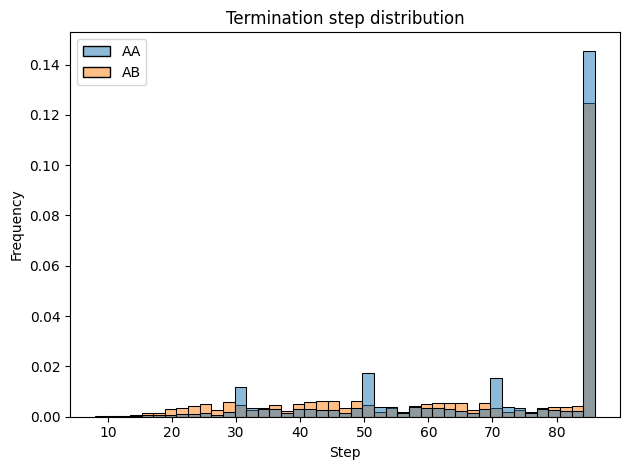

In [18]:
n_experiments = 10000
n = get_sample_size(alpha, beta, p0, p1)

plot_wald_termination_step_distribution(
    n_experiments, n, pdf_a_norm, pdf_b_norm, alpha, beta
)

## Задание 3 (3 балла). Разность бернуллиевских СВ

Замените приближение нормальным распределением в функциях `pdf_a` и `pdf_b` на их аналоги для разности двух бернуллиевских случайных величин. Повторите эксперименты из задания 2.

- Оцените вероятности ошибок первого и второго рода. Корректно ли работает критерий?
- Оцените средний размер групп до остановки теста.

100%|██████████| 10000/10000 [00:00<00:00, 15047.13it/s]


Type I error rate: 0.0691
Type II error rate: 0.0842
Average termination step for AA: 51.0186
Average termination step for AB: 44.7853


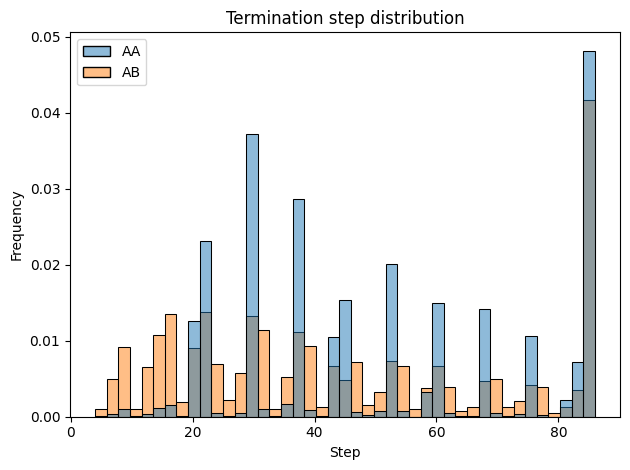

In [21]:
def pdf_a_binom(x: np.ndarray) -> np.ndarray:
    map = {
        -1: p0 * (1 - p0),
        0: p0 * p0 + (1 - p0) * (1 - p0),
        1: p0 * (1 - p0),
    }
    return np.array([map[i] for i in x])


def pdf_b_binom(x: np.ndarray) -> np.ndarray:
    map = {
        -1: p0 * (1 - p1),
        0: p0 * p1 + (1 - p0) * (1 - p1),
        1: p1 * (1 - p0),
    }
    return np.array([map[i] for i in x])


n_experiments = 10000
n = get_sample_size(alpha, beta, p0, p1)

plot_wald_termination_step_distribution(
    n_experiments, n, pdf_a_binom, pdf_b_binom, alpha, beta
)

## Задание 4 (2 балла). Сравнение методов

Сравните подходы из 2-го и 3-го заданий. У кого больше вероятность ошибки первого рода, вероятность ошибки второго рода, среднее количество размеров групп? Отличия статистически значимые?

По результатам экспериментов можно видеть, что при использовании нормального распределения в критерии Вальда вероятности ошибок первого и второго рода меньше, чем при использовании точного биномиального распределения. Это компенсируется тем, что в среднем при использовании точного биномиального распределения требуется меньший размер группы до остановки теста. 

Различия в показателях статистически значимы, но в обоих случаях ошибки не превышают заданные уровни $0.1$